# Comparação dos cinco classificadores — jogo da velha

Amanda Wilmsen e Kamilah Santos.

Reunimos **k-NN, árvore de decisão, Random Forest, MLP e SVM** nas duas abordagens.
O objetivo é comparar reconhecimento das quatro classes, possível sobreajuste e custo,
e justificar a escolha do **SVM com A2** para a aplicação.

Execute este notebook depois dos cinco experimentos. Ele lê os resultados exportados,
confere as configurações e mede novamente o custo sob condições comuns. Os CSVs
e gráficos ficam em `comparacao/resultados/`, prontos para apoiar o PPT.

## 1. Protocolo e limites da comparação

Todos os experimentos compartilham treino, validação e teste: 560 registros no treino
(431 tabuleiros distintos), 92 na validação e 93 no teste. A1 tem nove casas numéricas;
A2 tem 15 características derivadas. `estado` e `id_tabuleiro` não entram no modelo.

Cada notebook escolheu parâmetros e representação pela **validação**. Aqui não
criamos outra grade, não alteramos parâmetros e não refazemos treino com validação
ou teste. Reconstituímos as configurações fixadas e comparamos suas previsões com
os arquivos dos experimentos. As repetições de ajuste servem apenas à medição de custo.

A escolha final considera qualidade na validação, diferença treino–validação, custo
e resultados de teste já disponíveis. Esta análise é uma consolidação dos experimentos;
o teste não constitui uma nova avaliação independente posterior à escolha final.
Não interpretamos diferenças pequenas como superioridade estatística comprovada.

Precisão, recall e F1 usam **média macro**, com peso igual para as quatro classes.
A acurácia utiliza todos os exemplos. Os valores das tabelas variam de zero a um.

In [1]:
import hashlib
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from threadpoolctl import threadpool_limits

## 2. Caminhos, fontes e ordem dos algoritmos

Cada algoritmo mantém seu notebook e sua pasta `resultados/`. A consolidação lê os
resumos, as configurações selecionadas, as métricas e as previsões. O modelo escolhido
de cada experimento permanece no arquivo exportado; não o sobrescrevemos aqui.

In [2]:
RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "dataset/processado/resumo_preparacao.json").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Execute o notebook dentro deste projeto.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from front_end.jogo import extrair_entradas

BASE = RAIZ / "dataset/processado"
PASTA_RESULTADOS = BASE / "comparacao/resultados"
CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
ALGORITMOS = {
    "knn": ("k-NN", "knn"),
    "arvore": ("Árvore de decisão", "arvoreDecisao"),
    "random_forest": ("Random Forest", "randomForest"),
    "mlp": ("MLP", "mlp"),
    "svm": ("SVM", "svm"),
}
ABORDAGENS = {"abordagem_1": "A1 (tabuleiro)", "abordagem_2": "A2 (características)"}
figuras = {}
arquivos_fonte = []

## 3. Conferir as divisões e a procedência dos resultados

Conferimos que as duas representações mantêm os mesmos IDs, rótulos e ordem, sem
IDs compartilhados entre divisões. Os hashes dos resumos identificam os CSVs usados
por cada algoritmo; divergência interrompe a consolidação para evitar misturar bases.
Conferimos também a versão de scikit-learn dos modelos persistidos.

In [3]:
dados = {}
for ab in ABORDAGENS:
    dados[ab] = {}
    for conjunto in ["treino", "validacao", "teste"]:
        path = BASE / ab / f"{conjunto}.csv"
        df = pd.read_csv(path)
        arquivos_fonte.append(path)
        dados[ab][conjunto] = {
            "X": df.drop(columns=["id_tabuleiro", "estado"]),
            "y": df["estado"].to_numpy(), "ids": df["id_tabuleiro"].to_numpy(),
        }
for conjunto in ["treino", "validacao", "teste"]:
    assert np.array_equal(dados["abordagem_1"][conjunto]["ids"], dados["abordagem_2"][conjunto]["ids"])
    assert np.array_equal(dados["abordagem_1"][conjunto]["y"], dados["abordagem_2"][conjunto]["y"])
ids = {c: set(dados["abordagem_1"][c]["ids"]) for c in ["treino", "validacao", "teste"]}
assert not (ids["treino"] & ids["validacao"] or ids["treino"] & ids["teste"] or ids["validacao"] & ids["teste"])

resumos = {}
for chave, (_, pasta) in ALGORITMOS.items():
    arquivo = BASE / pasta / "resultados/resumo_experimento.json"
    resumos[chave] = json.loads(arquivo.read_text())
    arquivos_fonte.append(arquivo)
    assert resumos[chave]["versoes"]["scikit_learn"] == sklearn.__version__, chave
    for rel, esperado in resumos[chave]["csvs_entrada_sha256"].items():
        assert hashlib.sha256((RAIZ / rel).read_bytes()).hexdigest() == esperado, rel
print("Mesmas divisões e hashes dos cinco experimentos conferidos.")

Mesmas divisões e hashes dos cinco experimentos conferidos.


## 4. Reunir configurações e métricas de treino, validação e teste

São dez linhas: cinco algoritmos em duas representações. As tabelas dos experimentos
contêm valores completos; o arredondamento é apenas para apresentação. A diferença
`F1_treino − F1_validação` é calculada para a mesma configuração, não entre máximos
de configurações distintas.

In [4]:
linhas = []
configuracoes = []
previsoes_originais = {}
for chave, (nome, pasta) in ALGORITMOS.items():
    base = BASE / pasta / "resultados"
    selecao = pd.read_csv(base / "configuracoes_selecionadas.csv")
    metricas_salvas = pd.read_csv(base / "metricas_teste.csv")
    previsoes_originais[chave] = pd.read_csv(base / "previsoes_teste.csv")
    arquivos_fonte.extend(base / arq for arq in ["configuracoes_selecionadas.csv", "metricas_teste.csv", "previsoes_teste.csv"])
    for ab in ABORDAGENS:
        s = selecao.loc[selecao["codigo_abordagem"] == ab].iloc[0]
        t = metricas_salvas.loc[metricas_salvas["codigo_abordagem"] == ab].iloc[0]
        params = resumos[chave]["configuracoes_selecionadas"][ab]
        linhas.append({
            "chave": chave, "algoritmo": nome, "codigo_abordagem": ab,
            "abordagem": ABORDAGENS[ab], "n_features": dados[ab]["treino"]["X"].shape[1],
            "f1_treino": s["f1_treino"], "f1_validacao": s["val_f1_macro"],
            "acuracia_validacao": s["val_acc"],
            "gap_treino_val": s["f1_treino"] - s["val_f1_macro"],
            **{col: t[col] for col in ["acuracia", "precision", "recall", "f1_macro"]},
            "tempo_treino_notebook_ms": t["tempo_treino_ms"],
            "tempo_pred_notebook_ms": t["tempo_pred_ms"],
        })
        topologia = " → ".join(map(str, [dados[ab]["treino"]["X"].shape[1], *params["camadas"], 4])) if chave == "mlp" else "Não se aplica"
        configuracoes.append({"algoritmo": nome, "codigo_abordagem": ab,
                              "parametros": json.dumps(params, ensure_ascii=False), "topologia_mlp": topologia})
tabela = pd.DataFrame(linhas)
configuracoes = pd.DataFrame(configuracoes)
display(configuracoes)
display(tabela[["algoritmo", "abordagem", "f1_treino", "f1_validacao", "gap_treino_val",
                "acuracia", "precision", "recall", "f1_macro"]].round(4))

,algoritmo,codigo_abordagem,parametros,topologia_mlp
0,k-NN,abordagem_1,"{""k"": 7, ""metrica"": ""manhattan"", ""pesos"": ""uni...",Não se aplica
1,k-NN,abordagem_2,"{""k"": 3, ""metrica"": ""manhattan"", ""pesos"": ""uni...",Não se aplica
2,Árvore de decisão,abordagem_1,"{""criterio"": ""gini"", ""max_depth"": 8, ""min_leaf...",Não se aplica
3,Árvore de decisão,abordagem_2,"{""criterio"": ""gini"", ""max_depth"": 8, ""min_leaf...",Não se aplica
4,Random Forest,abordagem_1,"{""n_arvores"": 200, ""max_depth"": null, ""min_lea...",Não se aplica
5,Random Forest,abordagem_2,"{""n_arvores"": 10, ""max_depth"": null, ""min_leaf...",Não se aplica
6,MLP,abordagem_1,"{""camadas"": [64, 32], ""ativacao"": ""relu"", ""alp...",9 → 64 → 32 → 4
7,MLP,abordagem_2,"{""camadas"": [64, 32], ""ativacao"": ""relu"", ""alp...",15 → 64 → 32 → 4
8,SVM,abordagem_1,"{""kernel"": ""rbf"", ""C"": 100.0, ""gamma"": 0.01}",Não se aplica
9,SVM,abordagem_2,"{""kernel"": ""linear"", ""C"": 1.0, ""gamma"": null}",Não se aplica


,algoritmo,abordagem,f1_treino,f1_validacao,gap_treino_val,acuracia,precision,recall,f1_macro
0,k-NN,A1 (tabuleiro),0.8287,0.6516,0.1771,0.6559,0.5625,0.5083,0.5174
1,k-NN,A2 (características),0.9475,0.8861,0.0614,0.8817,0.9080,0.9083,0.9073
2,Árvore de decisão,A1 (tabuleiro),0.9464,0.5193,0.4271,0.6667,0.5091,0.5167,0.5126
3,Árvore de decisão,A2 (características),0.9801,0.9485,0.0316,0.9032,0.9248,0.9250,0.9245
4,Random Forest,A1 (tabuleiro),0.9928,0.7673,0.2255,0.7527,0.6913,0.7333,0.7056
5,Random Forest,A2 (características),0.9856,0.9397,0.0459,0.9032,0.9251,0.9250,0.9242
6,MLP,A1 (tabuleiro),1.0000,0.8087,0.1913,0.8495,0.7224,0.7333,0.7166
7,MLP,A2 (características),0.9910,0.9490,0.0420,0.9140,0.9329,0.9333,0.9327
8,SVM,A1 (tabuleiro),0.9236,0.7468,0.1768,0.8387,0.8228,0.8750,0.8367
9,SVM,A2 (características),0.9637,0.9485,0.0151,0.9462,0.9625,0.9583,0.9575


## 5. Verificar as configurações sem fazer nova busca

Carregamos o modelo exportado da abordagem recomendada. Para a outra abordagem,
reconstituímos somente sua configuração já selecionada e ajustamos no treino.
Conferimos F1 de treino/validação, as quatro métricas de teste e cada previsão com
os registros existentes. Essa verificação não escolhe novos parâmetros.

In [5]:
def metricas(y_real, previsto):
    return {
        "acuracia": accuracy_score(y_real, previsto),
        "precision": precision_score(y_real, previsto, labels=CLASSES, average="macro", zero_division=0),
        "recall": recall_score(y_real, previsto, labels=CLASSES, average="macro", zero_division=0),
        "f1_macro": f1_score(y_real, previsto, labels=CLASSES, average="macro", zero_division=0),
    }

def construir_modelo(chave, ab):
    p = resumos[chave]["configuracoes_selecionadas"][ab]
    if chave == "knn":
        modelo = KNeighborsClassifier(n_neighbors=p["k"], metric=p["metrica"], weights=p["pesos"])
        return make_pipeline(StandardScaler(), modelo) if ab == "abordagem_2" else modelo
    if chave == "arvore":
        return DecisionTreeClassifier(random_state=42, criterion=p["criterio"],
                                      max_depth=p["max_depth"], min_samples_leaf=p["min_leaf"])
    if chave == "random_forest":
        return RandomForestClassifier(random_state=42, n_estimators=p["n_arvores"],
                                      max_depth=p["max_depth"], min_samples_leaf=p["min_leaf"])
    if chave == "mlp":
        return make_pipeline(StandardScaler(), MLPClassifier(
            hidden_layer_sizes=tuple(p["camadas"]), activation=p["ativacao"], alpha=p["alpha"],
            **resumos[chave]["parametros_fixos"],
        ))
    kwargs = {"kernel": p["kernel"], "C": p["C"], **resumos[chave]["parametros_fixos"]}
    if p["kernel"] == "rbf":
        kwargs["gamma"] = p["gamma"]
    return make_pipeline(StandardScaler(), SVC(**kwargs))

modelos = {}
with threadpool_limits(limits=1), warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    # Preservamos o parâmetro original; seu aviso de descontinuação não entra na medição.
    warnings.filterwarnings("ignore", message=r"The `probability` parameter was deprecated in 1\.9.*",
                            category=FutureWarning, module=r"sklearn\.svm\._base")
    for chave, (_, pasta) in ALGORITMOS.items():
        for ab in ABORDAGENS:
            if ab == resumos[chave]["abordagem_escolhida_pela_validacao"]:
                arquivo = BASE / pasta / "resultados" / f"modelo_{chave}.joblib"
                modelo = joblib.load(arquivo)
                arquivos_fonte.append(arquivo)
            else:
                modelo = construir_modelo(chave, ab)
                modelo.fit(dados[ab]["treino"]["X"], dados[ab]["treino"]["y"])
            row = tabela.loc[(tabela["chave"] == chave) & (tabela["codigo_abordagem"] == ab)].iloc[0]
            for conjunto, coluna in [("treino", "f1_treino"), ("validacao", "f1_validacao")]:
                d = dados[ab][conjunto]
                assert np.isclose(metricas(d["y"], modelo.predict(d["X"]))["f1_macro"], row[coluna], atol=1e-12), (chave, ab, conjunto)
            d = dados[ab]["teste"]
            pred = modelo.predict(d["X"])
            original = previsoes_originais[chave].loc[previsoes_originais[chave]["abordagem"] == ab]
            assert np.array_equal(original["id_tabuleiro"].to_numpy(), d["ids"])
            assert np.array_equal(original["estado_real"].to_numpy(), d["y"])
            assert np.array_equal(original["estado_previsto"].to_numpy(), pred), (chave, ab)
            for coluna, valor in metricas(d["y"], pred).items():
                assert np.isclose(row[coluna], valor, atol=1e-12), (chave, ab, coluna)
            modelos[chave, ab] = modelo
print("Dez configurações e todas as previsões de teste conferidas.")

Dez configurações e todas as previsões de teste conferidas.


## 6. Medir custo com o mesmo protocolo

Medimos 20 ajustes e 20 previsões de cada configuração, na mesma execução e com
uma thread. A construção do estimador e a leitura dos arquivos ficam fora do relógio.
Registramos média e desvio padrão; as repetições não são novas amostras de desempenho.

Distinguimos três custos: **ajuste no treino**, **previsão do lote já preparado** e
**obtenção das características + DataFrame + previsão** a partir dos 93 tabuleiros.
O último custo inclui o pré-processamento das casas, mas não HTTP, navegador ou gravação
de registros. Não é a latência de uma única jogada na interface.

Tempos podem oscilar com a carga do computador. As medições deste notebook substituem
a comparação direta dos tempos de execuções anteriores; estes continuam registrados
nas colunas `tempo_*_notebook_ms` para referência.

In [6]:
REPETICOES_TEMPO = 20

def resumir_duracoes(valores, nome):
    return {nome: float(np.mean(valores)), nome.replace("_ms", "_desvio_ms"): float(np.std(valores))}

def preparar_tabuleiros(ab):
    # O ID recupera as casas para esta medição; não é fornecido ao classificador.
    d = dados[ab]["teste"]
    return pd.DataFrame([extrair_entradas(list(t), ab) for t in d["ids"]], columns=d["X"].columns)

custos_representacoes = []
for ab in ABORDAGENS:
    pd.testing.assert_frame_equal(preparar_tabuleiros(ab), dados[ab]["teste"]["X"], check_dtype=False)
    duracoes = []
    for _ in range(REPETICOES_TEMPO):
        inicio = time.perf_counter()
        preparar_tabuleiros(ab)
        duracoes.append((time.perf_counter() - inicio) * 1000)
    custos_representacoes.append({"codigo_abordagem": ab, "abordagem": ABORDAGENS[ab],
                                 "n_features": dados[ab]["teste"]["X"].shape[1],
                                 **resumir_duracoes(duracoes, "tempo_extracao_ms")})
custos_representacoes = pd.DataFrame(custos_representacoes)

custos = []
with threadpool_limits(limits=1), warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    # Preservamos o parâmetro original; seu aviso de descontinuação não entra na medição.
    warnings.filterwarnings("ignore", message=r"The `probability` parameter was deprecated in 1\.9.*",
                            category=FutureWarning, module=r"sklearn\.svm\._base")
    for (chave, ab), modelo in modelos.items():
        print("Medindo:", ALGORITMOS[chave][0], ABORDAGENS[ab], flush=True)
        d = dados[ab]
        ajustes, predicoes, completos = [], [], []
        for _ in range(REPETICOES_TEMPO):
            novo = clone(modelo)
            inicio = time.perf_counter()
            novo.fit(d["treino"]["X"], d["treino"]["y"])
            ajustes.append((time.perf_counter() - inicio) * 1000)
        # Aquecimento da previsão fora da medição, igual para os dez casos.
        modelo.predict(d["teste"]["X"])
        for _ in range(REPETICOES_TEMPO):
            inicio = time.perf_counter()
            modelo.predict(d["teste"]["X"])
            predicoes.append((time.perf_counter() - inicio) * 1000)
            inicio = time.perf_counter()
            modelo.predict(preparar_tabuleiros(ab))
            completos.append((time.perf_counter() - inicio) * 1000)
        custos.append({"chave": chave, "codigo_abordagem": ab,
                       **resumir_duracoes(ajustes, "tempo_treino_ms"),
                       **resumir_duracoes(predicoes, "tempo_pred_ms"),
                       **resumir_duracoes(completos, "tempo_extracao_pred_ms")})
custos = pd.DataFrame(custos)
tabela = tabela.merge(custos, on=["chave", "codigo_abordagem"], validate="one_to_one")
display(custos_representacoes.round(4))
display(tabela[["algoritmo", "abordagem", "tempo_treino_ms", "tempo_treino_desvio_ms",
                "tempo_pred_ms", "tempo_pred_desvio_ms", "tempo_extracao_pred_ms"]].round(4))

Medindo: k-NN A1 (tabuleiro)
Medindo: k-NN A2 (características)
Medindo: Árvore de decisão A1 (tabuleiro)
Medindo: Árvore de decisão A2 (características)
Medindo: Random Forest A1 (tabuleiro)
Medindo: Random Forest A2 (características)
Medindo: MLP A1 (tabuleiro)
Medindo: MLP A2 (características)
Medindo: SVM A1 (tabuleiro)
Medindo: SVM A2 (características)


,codigo_abordagem,abordagem,n_features,tempo_extracao_ms,tempo_extracao_desvio_ms
0,abordagem_1,A1 (tabuleiro),9,0.2114,0.0092
1,abordagem_2,A2 (características),15,0.8024,0.0047


,algoritmo,abordagem,tempo_treino_ms,tempo_treino_desvio_ms,tempo_pred_ms,tempo_pred_desvio_ms,tempo_extracao_pred_ms
0,k-NN,A1 (tabuleiro),0.7043,0.0623,0.9783,0.0233,1.2331
1,k-NN,A2 (características),1.2621,0.0486,1.0915,0.0138,1.9279
2,Árvore de decisão,A1 (tabuleiro),1.1579,0.0354,0.2287,0.0052,0.4403
3,Árvore de decisão,A2 (características),1.0536,0.0238,0.2453,0.0041,1.0484
4,Random Forest,A1 (tabuleiro),139.0523,47.0567,6.3271,0.2707,6.5138
5,Random Forest,A2 (características),6.8216,0.2257,0.6723,0.1084,1.5839
6,MLP,A1 (tabuleiro),1141.2348,68.0991,0.3874,0.0180,0.6304
7,MLP,A2 (características),1064.8851,66.2979,0.4482,0.0449,1.2992
8,SVM,A1 (tabuleiro),14.3272,0.1649,1.3266,0.0277,1.5624
9,SVM,A2 (características),2.8071,0.0420,0.5339,0.0636,1.3762


## 7. Comparar as quatro métricas no teste

Cada barra representa a configuração selecionada pela validação. As quatro métricas
permanecem separadas: acurácia e F1 macro não são intercambiáveis. O eixo usa a mesma
escala nas duas representações e nos cinco algoritmos.

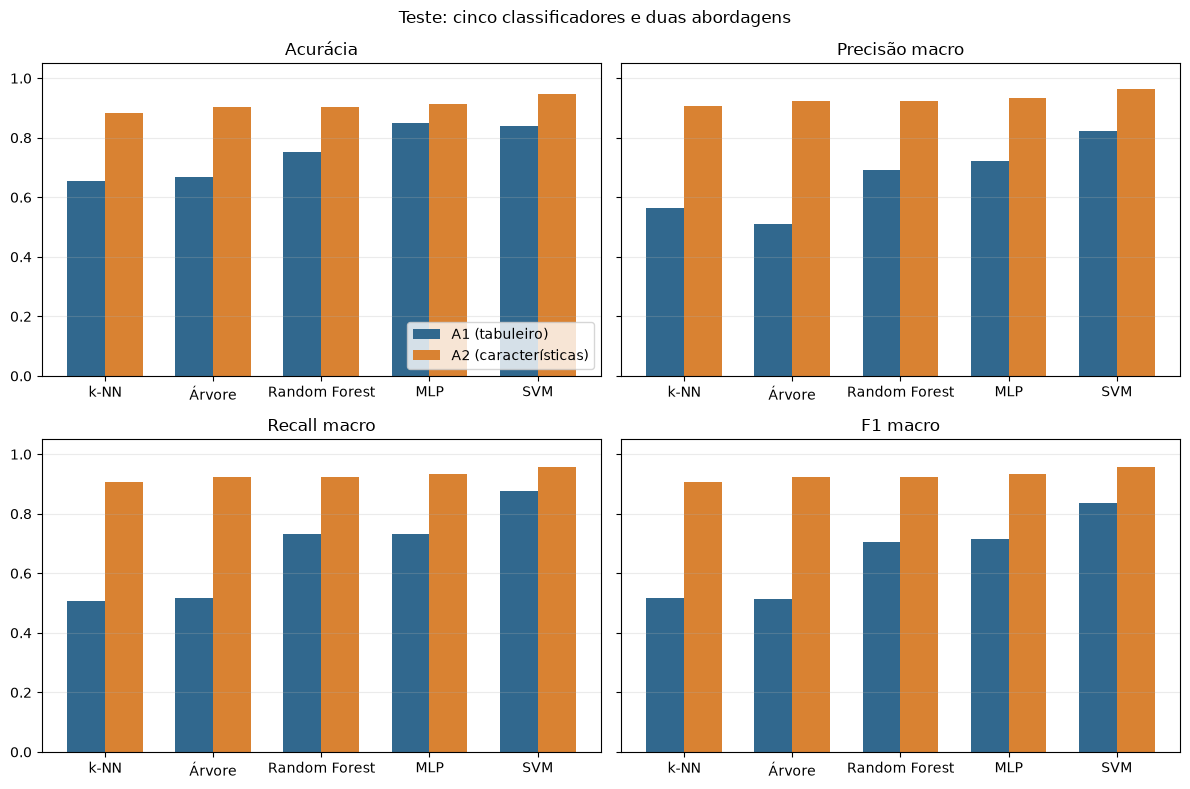

In [7]:
ordem = list(ALGORITMOS)
rotulos = ["k-NN", "Árvore", "Random Forest", "MLP", "SVM"]
cores = ["#31688e", "#d98232"]
x = np.arange(len(ordem))
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, (metrica, titulo) in zip(axs.flat, [("acuracia", "Acurácia"), ("precision", "Precisão macro"),
                                         ("recall", "Recall macro"), ("f1_macro", "F1 macro")]):
    for i, ab in enumerate(ABORDAGENS):
        s = tabela.loc[tabela["codigo_abordagem"] == ab].set_index("chave").loc[ordem]
        ax.bar(x + (i - 0.5) * 0.35, s[metrica], width=0.35, color=cores[i], label=ABORDAGENS[ab])
    ax.set_xticks(x, rotulos)
    ax.set_ylim(0, 1.05)
    ax.set_title(titulo)
    ax.grid(axis="y", alpha=0.25)
axs[0, 0].legend(loc="lower right")
fig.suptitle("Teste: cinco classificadores e duas abordagens")
fig.tight_layout()
figuras["metricas_teste"] = fig
plt.show()

## 8. Analisar treino e validação

As duas curvas utilizam as mesmas configurações em cada ponto. Uma diferença grande
é um indício de possível sobreajuste. Uma diferença pequena não garante desempenho
estável, especialmente com poucos empates e repetição de exemplos no treino.

A comparação é entre configurações finais, não entre épocas de treinamento. A1 e A2
também podem ter parâmetros distintos; a representação não é a única variável que muda.

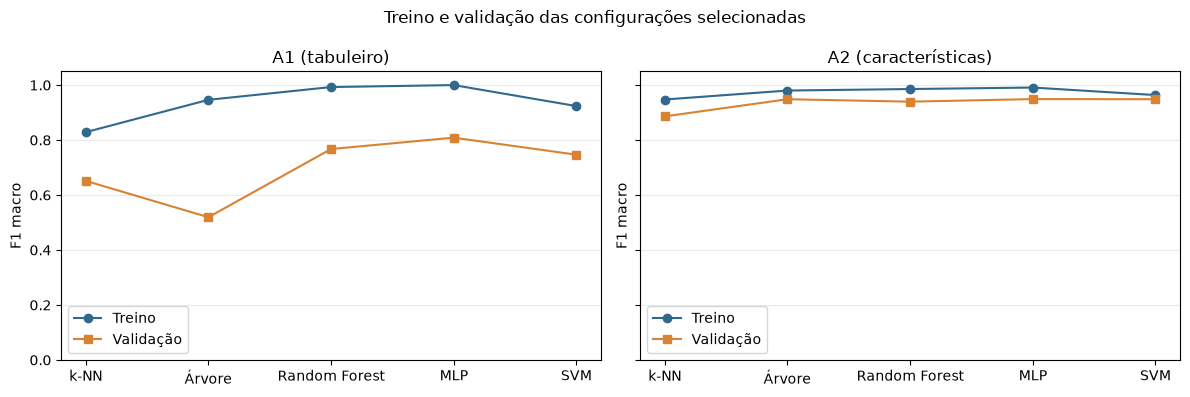

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, ab in zip(axs, ABORDAGENS):
    s = tabela.loc[tabela["codigo_abordagem"] == ab].set_index("chave").loc[ordem]
    ax.plot(x, s["f1_treino"], marker="o", label="Treino", color="#31688e")
    ax.plot(x, s["f1_validacao"], marker="s", label="Validação", color="#d98232")
    ax.set_xticks(x, rotulos)
    ax.set_ylim(0, 1.05)
    ax.set_title(ABORDAGENS[ab])
    ax.set_ylabel("F1 macro")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
fig.suptitle("Treino e validação das configurações selecionadas")
fig.tight_layout()
figuras["treino_validacao"] = fig
plt.show()

## 9. Comparar custo do modelo e da representação

O gráfico de custo usa escala logarítmica, porque os tempos de ajuste diferem muito.
As barras mostram médias; os desvios padrão permanecem nas tabelas. Diferenças de
frações de milissegundo precisam ser interpretadas com a dispersão das medições.

O custo da representação é mostrado separadamente. A2 contém mais atributos e
calcula contagens e alinhamentos; isso pode custar mais do que codificar as nove casas.
Portanto, uma boa representação não precisa ser a mais barata em todas as etapas.

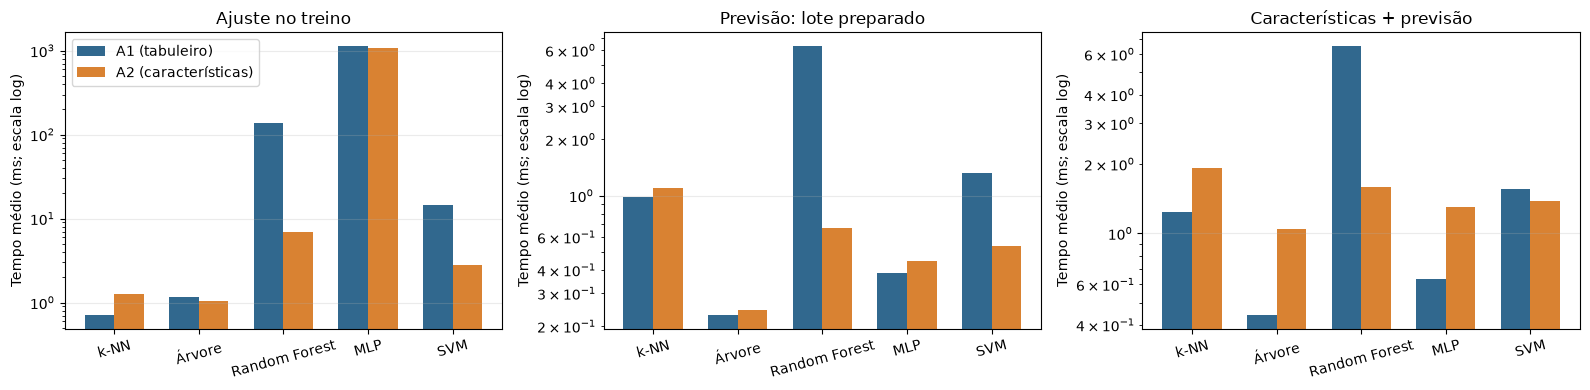

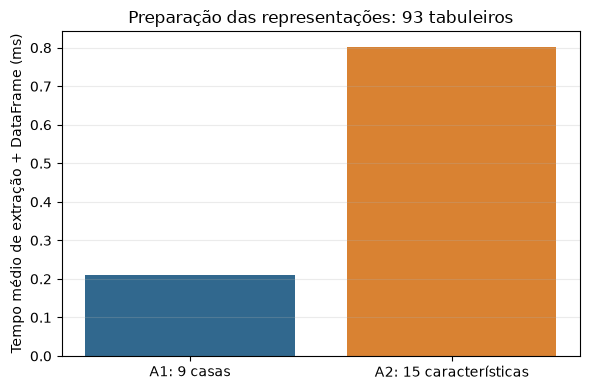

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, (metrica, titulo) in zip(axs, [("tempo_treino_ms", "Ajuste no treino"),
                                    ("tempo_pred_ms", "Previsão: lote preparado"),
                                    ("tempo_extracao_pred_ms", "Características + previsão")]):
    for i, ab in enumerate(ABORDAGENS):
        s = tabela.loc[tabela["codigo_abordagem"] == ab].set_index("chave").loc[ordem]
        ax.bar(x + (i - 0.5) * 0.35, s[metrica], width=0.35, color=cores[i], label=ABORDAGENS[ab])
    ax.set_xticks(x, rotulos, rotation=15)
    ax.set_yscale("log")
    ax.set_ylabel("Tempo médio (ms; escala log)")
    ax.set_title(titulo)
    ax.grid(axis="y", alpha=0.25)
axs[0].legend()
fig.tight_layout()
figuras["custo_controlado"] = fig
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["A1: 9 casas", "A2: 15 características"], custos_representacoes["tempo_extracao_ms"], color=cores)
ax.set_ylabel("Tempo médio de extração + DataFrame (ms)")
ax.set_title("Preparação das representações: 93 tabuleiros")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
figuras["custo_representacoes"] = fig
plt.show()

## 10. Justificar a escolha do SVM com A2

A escolha considera o conjunto dos resultados e o custo da aplicação. A MLP tem
F1 de validação ligeiramente maior, por isso não afirmamos que o SVM liderou essa
métrica. A pequena diferença, a acurácia de validação, o menor afastamento entre
treino e validação do SVM e seu custo de ajuste sustentam a escolha de uma solução
linear mais simples de configurar.

Os resultados de teste apoiam a comparação descritiva dos modelos já avaliados.
Não alteramos parâmetros após ver o teste. Abaixo, a justificativa utiliza os
valores completos desta consolidação e as medições de custo desta execução.

In [10]:
a2 = tabela.loc[tabela["codigo_abordagem"] == "abordagem_2"].set_index("chave")
svm, mlp, arvore = [a2.loc[chave] for chave in ["svm", "mlp", "arvore"]]
p = resumos["svm"]["configuracoes_selecionadas"]["abordagem_2"]
texto_conclusao = (
    "**Escolha para a aplicação: SVM com A2**, usando padronização do treino, "
    f"kernel {p['kernel']} e C={p['C']:g}. A entrada tem 15 características; "
    "gamma não é um parâmetro ativo do kernel linear.\n\n"
    f"**Validação e generalização:** o SVM teve F1 macro {svm['f1_validacao']:.6f} "
    f"e acurácia {svm['acuracia_validacao']:.2%}. A MLP teve F1 {mlp['f1_validacao']:.6f}, "
    f"uma vantagem numérica de {100 * (mlp['f1_validacao'] - svm['f1_validacao']):.3f} "
    "pontos percentuais, sem comprovação de significância estatística. "
    f"A diferença treino–validação foi {svm['gap_treino_val']:.3f} no SVM, "
    f"{mlp['gap_treino_val']:.3f} na MLP e {arvore['gap_treino_val']:.3f} na árvore. "
    "O menor afastamento do SVM é favorável, mas não prova ausência de sobreajuste.\n\n"
    f"**Custo:** o ajuste do SVM levou em média {svm['tempo_treino_ms']:.2f} ms, "
    f"contra {mlp['tempo_treino_ms']:.2f} ms da MLP nesta medição. A previsão do lote "
    f"preparado levou {svm['tempo_pred_ms']:.3f} ms; incluir a extração e o DataFrame "
    f"levou {svm['tempo_extracao_pred_ms']:.3f} ms. A escolha não exige que o SVM seja "
    "o mais rápido em cada etapa; ela equilibra custo e qualidade.\n\n"
    f"**Teste:** o SVM alcançou acurácia {svm['acuracia']:.2%}, precisão macro "
    f"{svm['precision']:.4f}, recall macro {svm['recall']:.4f} e F1 macro "
    f"{svm['f1_macro']:.4f}. Foram os maiores valores dessas quatro métricas "
    "entre as dez configurações avaliadas nesta amostra. Não usamos esses resultados "
    "para redefinir a grade ou reajustar parâmetros."
)

for ab in ABORDAGENS:
    s = tabela.loc[tabela["codigo_abordagem"] == ab]
    texto_conclusao += (
        f"\n\n**{ABORDAGENS[ab]}:** diferenças treino–validação de "
        + "; ".join(f"{r.algoritmo}: {r.gap_treino_val:.3f}" for r in s.itertuples())
        + ". As diferenças de A1 foram maiores do que as de A2 nos cinco algoritmos."
    )
texto_conclusao += (
    "\n\n**Representações:** A2 melhorou o F1 de validação e teste dos cinco algoritmos "
    "nesta amostra. Seus 15 atributos resumem contagens e alinhamentos úteis, mas sua "
    "extração custa mais do que a codificação das nove casas. O custo completo também "
    "depende do classificador e dos parâmetros; não declaramos A2 universalmente mais rápida."
    "\n\n**Limitações e continuidade:** somente dois empates na validação e três no teste; "
    "repetição de empates apenas no treino; possíveis simetrias entre divisões; cinco "
    "grupos de A2 com características iguais e respostas diferentes; busca finita; "
    "medições sensíveis à carga do computador. Os resultados não garantem desempenho "
    "em qualquer partida. A avaliação durante as partidas "
    "deve ser registrada separadamente no relatório."
)
display(Markdown(texto_conclusao))

**Escolha para a aplicação: SVM com A2**, usando padronização do treino, kernel linear e C=1. A entrada tem 15 características; gamma não é um parâmetro ativo do kernel linear.

**Validação e generalização:** o SVM teve F1 macro 0.948533 e acurácia 93.48%. A MLP teve F1 0.949021, uma vantagem numérica de 0.049 pontos percentuais, sem comprovação de significância estatística. A diferença treino–validação foi 0.015 no SVM, 0.042 na MLP e 0.032 na árvore. O menor afastamento do SVM é favorável, mas não prova ausência de sobreajuste.

**Custo:** o ajuste do SVM levou em média 2.81 ms, contra 1064.89 ms da MLP nesta medição. A previsão do lote preparado levou 0.534 ms; incluir a extração e o DataFrame levou 1.376 ms. A escolha não exige que o SVM seja o mais rápido em cada etapa; ela equilibra custo e qualidade.

**Teste:** o SVM alcançou acurácia 94.62%, precisão macro 0.9625, recall macro 0.9583 e F1 macro 0.9575. Foram os maiores valores dessas quatro métricas entre as dez configurações avaliadas nesta amostra. Não usamos esses resultados para redefinir a grade ou reajustar parâmetros.

**A1 (tabuleiro):** diferenças treino–validação de k-NN: 0.177; Árvore de decisão: 0.427; Random Forest: 0.226; MLP: 0.191; SVM: 0.177. As diferenças de A1 foram maiores do que as de A2 nos cinco algoritmos.

**A2 (características):** diferenças treino–validação de k-NN: 0.061; Árvore de decisão: 0.032; Random Forest: 0.046; MLP: 0.042; SVM: 0.015. As diferenças de A1 foram maiores do que as de A2 nos cinco algoritmos.

**Representações:** A2 melhorou o F1 de validação e teste dos cinco algoritmos nesta amostra. Seus 15 atributos resumem contagens e alinhamentos úteis, mas sua extração custa mais do que a codificação das nove casas. O custo completo também depende do classificador e dos parâmetros; não declaramos A2 universalmente mais rápida.

**Limitações e continuidade:** somente dois empates na validação e três no teste; repetição de empates apenas no treino; possíveis simetrias entre divisões; cinco grupos de A2 com características iguais e respostas diferentes; busca finita; medições sensíveis à carga do computador. Os resultados não garantem desempenho em qualquer partida. A avaliação durante as partidas deve ser registrada separadamente no relatório.

## 11. Salvar tabelas, gráficos e conclusão para o relatório

Os CSVs mantêm os valores completos. Os PNGs são figuras independentes para inserir
no PPT. O resumo JSON identifica versões, condições de custo, configurações e hashes
das fontes. Não contém dados de partidas humanas misturados às métricas de teste.

In [11]:
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
tabela.to_csv(PASTA_RESULTADOS / "comparacao_completa.csv", index=False)
configuracoes.to_csv(PASTA_RESULTADOS / "configuracoes.csv", index=False)
custos_representacoes.to_csv(PASTA_RESULTADOS / "custo_representacoes.csv", index=False)
(PASTA_RESULTADOS / "conclusao.md").write_text(texto_conclusao + "\n", encoding="utf-8")
for nome, figura in figuras.items():
    figura.savefig(PASTA_RESULTADOS / f"{nome}.png", dpi=150, bbox_inches="tight")
resumo = {
    "algoritmo_escolhido": "svm", "abordagem_escolhida": "abordagem_2",
    "criterio": "Equilíbrio entre validação, diferença treino–validação e custo; comparação descritiva do teste",
    "parametros_escolhidos": resumos["svm"]["configuracoes_selecionadas"]["abordagem_2"],
    "configuracoes_fixadas": {chave: info["configuracoes_selecionadas"] for chave, info in resumos.items()},
    "versoes": {"python": platform.python_version(), "scikit_learn": sklearn.__version__,
                "numpy": np.__version__, "pandas": pd.__version__, "matplotlib": matplotlib.__version__},
    "plataforma": platform.platform(), "threads_blas": 1,
    "repeticoes_tempo": REPETICOES_TEMPO, "tabuleiros_por_lote": len(dados["abordagem_1"]["teste"]["X"]),
    "fontes_sha256": {str(p.relative_to(RAIZ)): hashlib.sha256(p.read_bytes()).hexdigest()
                      for p in dict.fromkeys(arquivos_fonte)},
}
(PASTA_RESULTADOS / "resumo_comparacao.json").write_text(json.dumps(resumo, ensure_ascii=False, indent=2) + "\n")
print("Comparação salva em:", PASTA_RESULTADOS.relative_to(RAIZ))
print("Recomendação: SVM, A2, kernel linear, C=1.")

Comparação salva em: dataset/processado/comparacao/resultados
Recomendação: SVM, A2, kernel linear, C=1.


## 12. Organização e referências

O fluxo do projeto é: preparação dos dados → cinco experimentos individuais → esta
comparação → avaliação no front → relatório. Cada classificador mantém
seu código, metadados e resultados; esta pasta reúne apenas a análise conjunta.

Referências didáticas: [métricas de classificação](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics),
[cuidados com vazamento de dados](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)
e [validação e teste](https://scikit-learn.org/stable/modules/cross_validation.html).